# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Exercise 2 — kNN with the Euclidean Distance Formula

**Goal:** Given the small labeled dataset below, calculate the **Euclidean distance** between a
new entry and every existing point, then classify the new entry by majority vote among its
**k** nearest neighbors.

| Brightness | Saturation | Class |
|---|---|---|
| 40 | 20 | Red |
| 50 | 50 | Blue |
| 60 | 90 | Blue |
| 10 | 25 | Red |
| 70 | 70 | Blue |
| 60 | 10 | Red |
| 25 | 80 | Blue |

**Euclidean distance formula** between point `(x1, y1)` and point `(x2, y2)`:

$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

sns.set_theme(style="whitegrid")


## 1. Build the dataset exactly as given

In [2]:
data = {
    "Brightness": [40, 50, 60, 10, 70, 60, 25],
    "Saturation": [20, 50, 90, 25, 70, 10, 80],
    "Class":      ["Red", "Blue", "Blue", "Red", "Blue", "Red", "Blue"],
}
df = pd.DataFrame(data)
df


,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue
5,60,10,Red
6,25,80,Blue


## 2. Define a new entry to classify

Let's classify a new specimen with **Brightness = 45, Saturation = 55** (feel free to change this).


In [3]:
new_entry = {"Brightness": 45, "Saturation": 55}
new_entry


{'Brightness': 45, 'Saturation': 55}

## 3. Calculate the Euclidean distance to every existing point, step by step

In [4]:
def euclidean_distance(p1, p2):
    """d = sqrt((x2-x1)^2 + (y2-y1)^2)"""
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)


new_point = (new_entry["Brightness"], new_entry["Saturation"])

distances = []
for _, row in df.iterrows():
    existing_point = (row["Brightness"], row["Saturation"])
    d = euclidean_distance(new_point, existing_point)
    distances.append(d)

df_dist = df.copy()
df_dist["Distance to new entry"] = np.round(distances, 3)
df_dist = df_dist.sort_values("Distance to new entry").reset_index(drop=True)
df_dist


,Brightness,Saturation,Class,Distance to new entry
0,50,50,Blue,7.071
1,70,70,Blue,29.155
2,25,80,Blue,32.016
3,40,20,Red,35.355
4,60,90,Blue,38.079
5,10,25,Red,46.098
6,60,10,Red,47.434


Each distance was computed as:

`d = sqrt((Brightness_new - Brightness_i)^2 + (Saturation_new - Saturation_i)^2)`

for every row `i` in the table, then sorted from nearest to farthest.


## 4. Classify the new entry using k-Nearest Neighbors

In [5]:
def knn_classify(df_sorted_by_distance, k):
    k_nearest = df_sorted_by_distance.iloc[:k]
    vote_counts = Counter(k_nearest["Class"])
    predicted_class = vote_counts.most_common(1)[0][0]
    return predicted_class, vote_counts, k_nearest


for k in [1, 3, 5]:
    predicted_class, vote_counts, k_nearest = knn_classify(df_dist, k)
    print(f"k={k}: nearest classes = {list(k_nearest['Class'])}  "
          f"-> vote counts = {dict(vote_counts)}  -> predicted class = {predicted_class}")


k=1: nearest classes = ['Blue']  -> vote counts = {'Blue': 1}  -> predicted class = Blue
k=3: nearest classes = ['Blue', 'Blue', 'Blue']  -> vote counts = {'Blue': 3}  -> predicted class = Blue
k=5: nearest classes = ['Blue', 'Blue', 'Blue', 'Red', 'Blue']  -> vote counts = {'Blue': 4, 'Red': 1}  -> predicted class = Blue


## 5. Visualize the dataset, the new point, and its nearest neighbors (k=3)

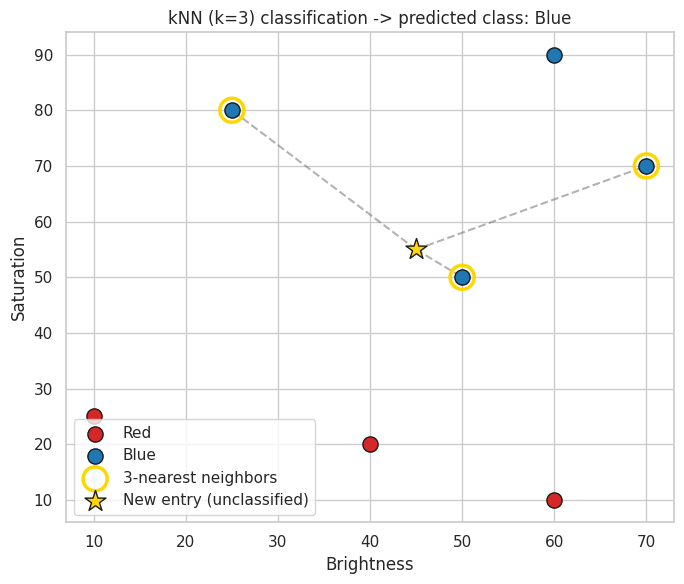

In [6]:
K = 3
predicted_class, vote_counts, k_nearest = knn_classify(df_dist, K)

plt.figure(figsize=(7, 6))
colors = {"Red": "#d62728", "Blue": "#1f77b4"}

for cls in df["Class"].unique():
    subset = df[df["Class"] == cls]
    plt.scatter(subset["Brightness"], subset["Saturation"], c=colors[cls], s=120,
                label=cls, edgecolor="k", zorder=3)

# Highlight the k nearest neighbors with a ring
plt.scatter(k_nearest["Brightness"], k_nearest["Saturation"], s=300,
            facecolors="none", edgecolors="gold", linewidths=2.5, zorder=4,
            label=f"{K}-nearest neighbors")

# Draw lines from the new point to its k nearest neighbors
for _, row in k_nearest.iterrows():
    plt.plot([new_point[0], row["Brightness"]], [new_point[1], row["Saturation"]],
              "--", color="gray", alpha=0.6, zorder=2)

plt.scatter(*new_point, c="gold", s=250, marker="*", edgecolor="k",
            label="New entry (unclassified)", zorder=5)

plt.xlabel("Brightness")
plt.ylabel("Saturation")
plt.title(f"kNN (k={K}) classification -> predicted class: {predicted_class}")
plt.legend()
plt.tight_layout()
plt.show()


## 6. General-purpose function: classify any new point against any dataset

Reusable version so you can try different new entries or different values of `k` easily.


In [7]:
def classify_new_point(new_point, df, k):
    """
    new_point: tuple (Brightness, Saturation)
    df: DataFrame with columns Brightness, Saturation, Class
    k: number of nearest neighbors to use
    """
    dists = df.apply(
        lambda row: euclidean_distance(new_point, (row["Brightness"], row["Saturation"])),
        axis=1
    )
    df_sorted = df.assign(Distance=dists).sort_values("Distance").reset_index(drop=True)
    k_nearest = df_sorted.iloc[:k]
    vote_counts = Counter(k_nearest["Class"])
    predicted_class = vote_counts.most_common(1)[0][0]
    return predicted_class, df_sorted


# Example: try a different new entry
test_point = (15, 30)
pred, ranked = classify_new_point(test_point, df, k=3)
print(f"New entry {test_point} classified as: {pred}")
ranked


New entry (15, 30) classified as: Red


,Brightness,Saturation,Class,Distance
0,10,25,Red,7.071068
1,40,20,Red,26.925824
2,50,50,Blue,40.311289
3,60,10,Red,49.244289
4,25,80,Blue,50.990195
5,70,70,Blue,68.007353
6,60,90,Blue,75.000000
